## 2D Random Walk
With constant magnitude of displacement for each time step.

In [340]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [341]:
displacement_mag = 1 #fixed the magnitude of discplacement to be constant
starting_position = np.array([0,0], dtype=float)

#generates a random direction
def generate_direction_vector():
    angle = np.random.uniform(0, 2*math.pi) #in radians
    x_direction = math.cos(angle)
    y_direction = math.sin(angle)
    return [x_direction, y_direction]

#given a time duration and starting position, produces a random walk trajectory
def generate_trajectory(time, starting_position):
    trajectory = []
    current_position = starting_position.copy() 
    current_time = 0
    while current_time < time:
        current_position += generate_direction_vector().copy()
        trajectory.append(np.concatenate((np.array([current_time]), current_position)))
        current_time += 1
    return trajectory 

In [ ]:
#calculate MSD 
def calculate_MSD(time_interval, trajectory):
    r2 = np.array([0,0], dtype=float)
    count = 0
    samples = trajectory[::time_interval]
    for i in range(1,len(samples)):
        r2 += ((samples[i] - samples[i-1])**2)[1:]
        count += 1
    msd = np.sum(r2)/(len(samples)-1)
    return msd

In [343]:
def generate_MSD_dataset(time, trajectory):
    time_data = [t for t in range(2,time+1)]
    msd_data = []
    for i in range(2, time+1):
        msd_data.append(calculate_MSD(i, trajectory))
    return [time_data, msd_data]

In [344]:
#particle1 = generate_trajectory(1000, starting_position)
particle2 = generate_trajectory(10, starting_position)
particle3 = generate_trajectory(1000, starting_position)

#print(particle1)
print(particle2)

print(calculate_MSD(2, particle2))
#print(calculate_MSD(10, particle1))
print(calculate_MSD(50, particle3))

[array([ 0.        , -0.01782266, -0.99984116]), array([ 1.        , -0.9794502 , -0.72548287]), array([ 2.        , -1.46026411, -1.60230554]), array([ 3.        , -2.44879232, -1.45126924]), array([ 4.        , -2.88944527, -2.34894678]), array([ 5.        , -3.72132329, -1.79398826]), array([ 6.        , -3.63547437, -0.7976801 ]), array([ 7.        , -4.569337  , -1.15531201]), array([ 8.        , -5.35659443, -1.77193649]), array([ 9.        , -5.7054956 , -2.70909601])]
2.9795125310627495
58.00956338188294


[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100]


Text(0, 0.5, 'MSD (m)')

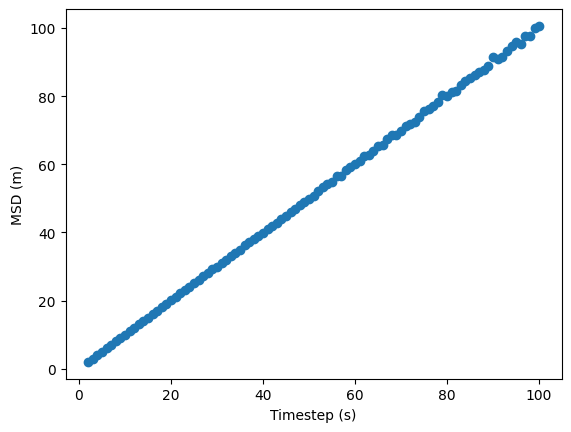

In [354]:
particle1 = generate_trajectory(1000000, starting_position)
particle1_data = generate_MSD_dataset(100, particle1)

plt.scatter(particle1_data[0], particle1_data[1])
print(particle1_data[0])
plt.xlabel('Timestep (s)')
plt.ylabel('MSD (m)' )

However, closer to actual Brownian motion, the magnitude of displacement need not be constant all the time… Instead it may be a more realistic simulation to choose a magnitude of displacement from a normal distribution for each time step. 

In [391]:
starting_position = np.array([0,0], dtype=float)

#generates a random direction
def generate_direction_vector():
    displacement_mag = np.random.normal(loc=1, scale=2)
    angle = np.random.uniform(0, 2*math.pi) #in radians
    x_direction = displacement_mag*math.cos(angle)
    y_direction = displacement_mag*math.sin(angle)
    #print(displacement_mag)
    return [x_direction, y_direction]

#given a time duration and starting position, produces a random walk trajectory
def generate_trajectory(time, starting_position):
    trajectory = []
    current_position = starting_position.copy() 
    current_time = 0
    while current_time < time:
        current_position += generate_direction_vector().copy()
        trajectory.append(np.concatenate((np.array([current_time]), current_position)))
        current_time += 1
    return trajectory 

#calculate MSD 
def calculate_MSD(time_interval, trajectory):
    r2 = np.array([0,0], dtype=float)
    count = 0
    samples = trajectory[::time_interval]
    for i in range(1,len(samples)):
        r2 += ((samples[i] - samples[i-1])**2)[1:]
        count += 1
    msd = np.sum(r2)/(len(samples)-1)
    return msd

def generate_MSD_dataset(time, trajectory):
    time_data = [t for t in range(2,time+1)]
    msd_data = []
    for i in range(2, time+1):
        msd_data.append(calculate_MSD(i, trajectory))
    return [time_data, msd_data]

[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100]


Text(0, 0.5, 'MSD (m)')

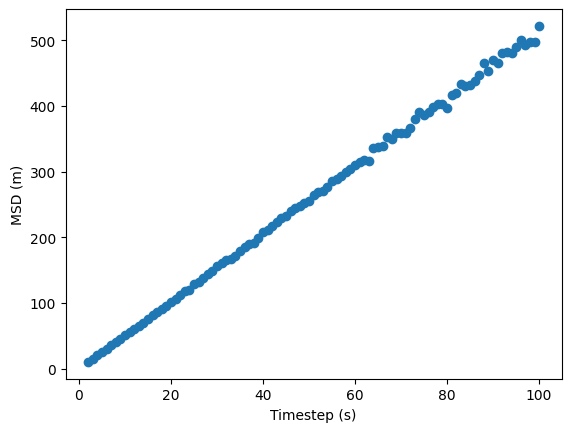

In [392]:
particle1 = generate_trajectory(100000, starting_position)
particle1_data = generate_MSD_dataset(100, particle1)

plt.scatter(particle1_data[0], particle1_data[1])
print(particle1_data[0])
plt.xlabel('Timestep (s)')
plt.ylabel('MSD (m)' )